In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\raw\External_Cibil_Dataset.csv')

In [5]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (51336, 62)

Data Types:
 PROSPECTID                       int64
time_since_recent_payment        int64
time_since_first_deliquency      int64
time_since_recent_deliquency     int64
num_times_delinquent             int64
                                 ...  
GL_Flag                          int64
last_prod_enq2                  object
first_prod_enq2                 object
Credit_Score                     int64
Approved_Flag                   object
Length: 62, dtype: object

Duplicate rows: 0


In [6]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("\n", missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))



 Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


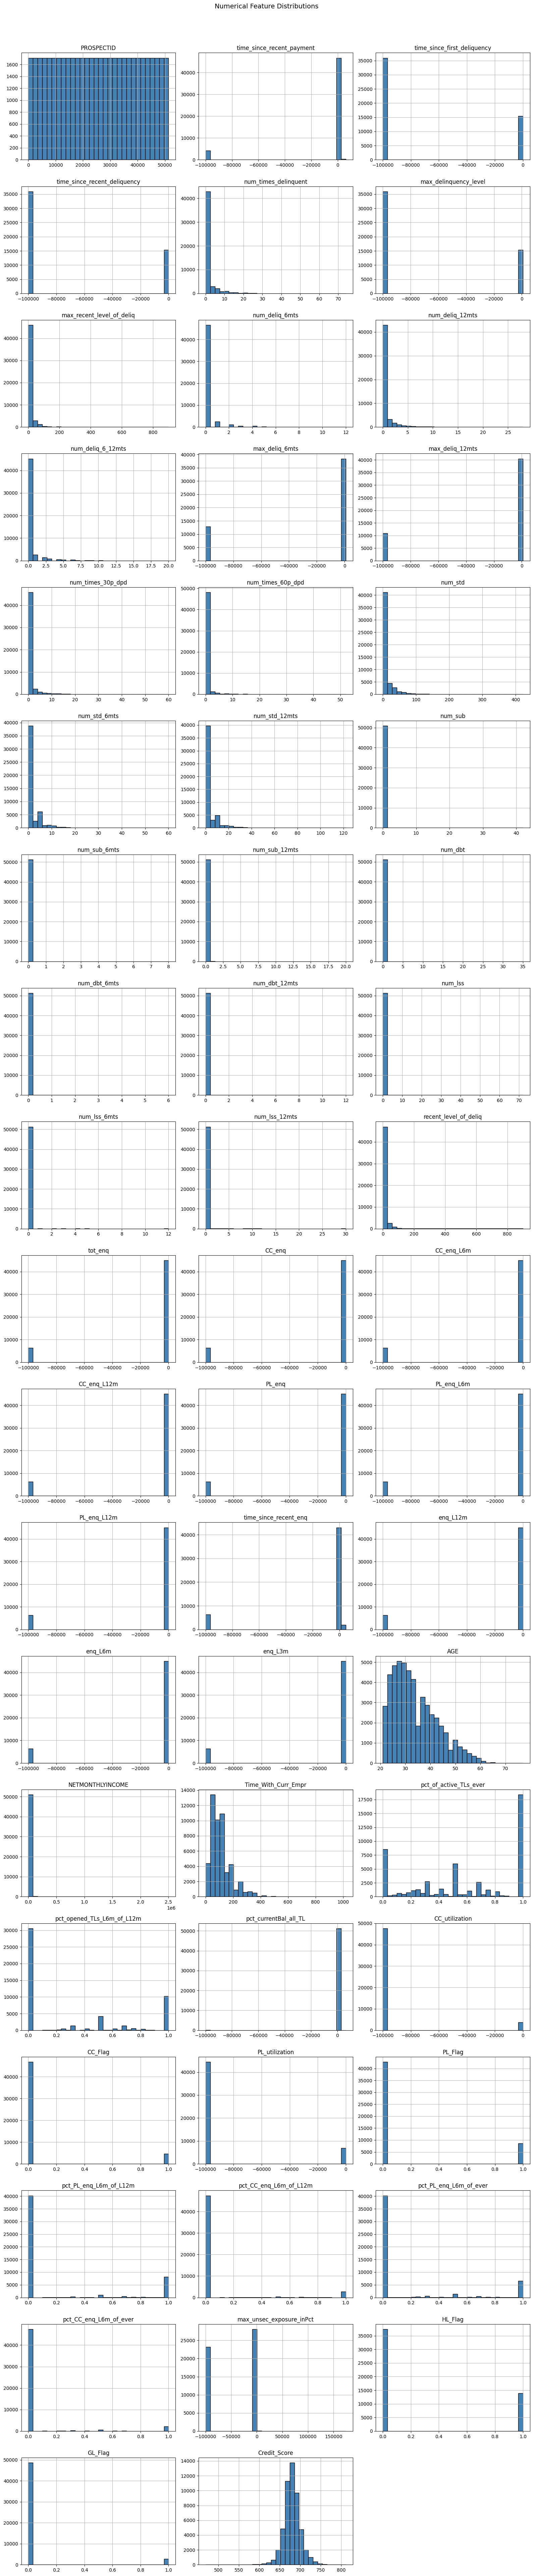

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Numerical — histograms + KDE
n = len(num_cols)
fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(16, (n+2)//3 * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

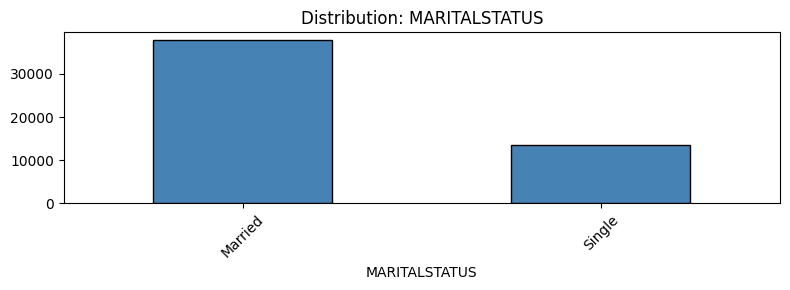

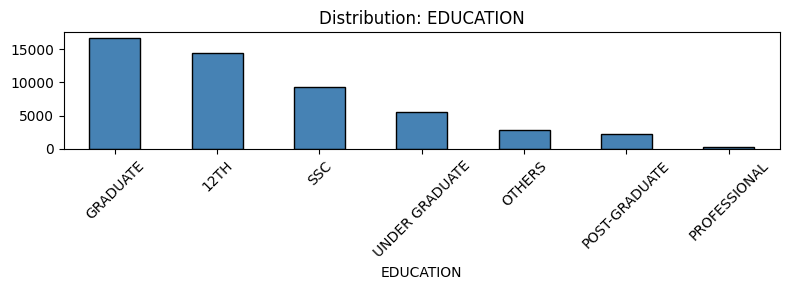

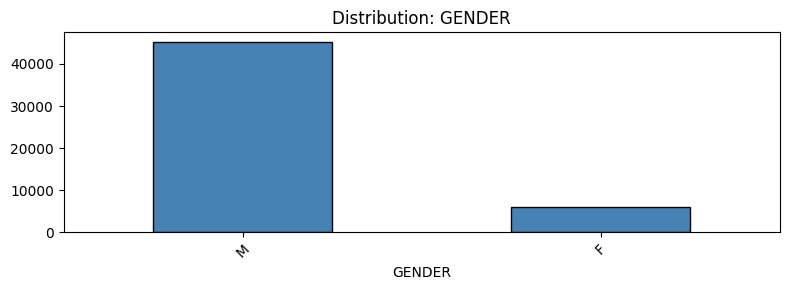

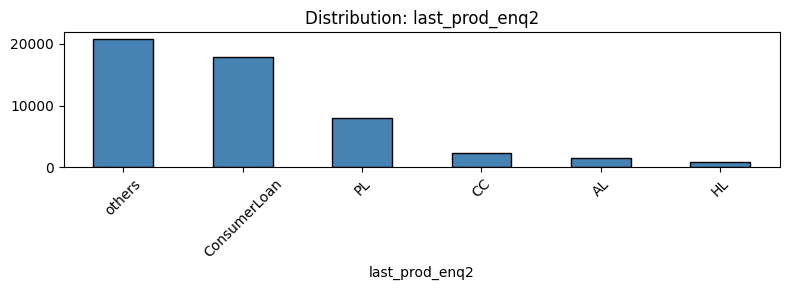

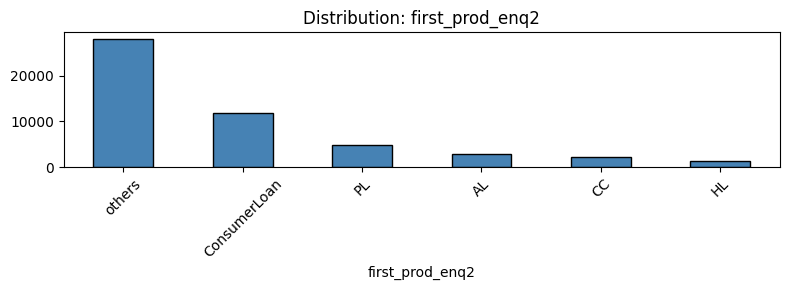

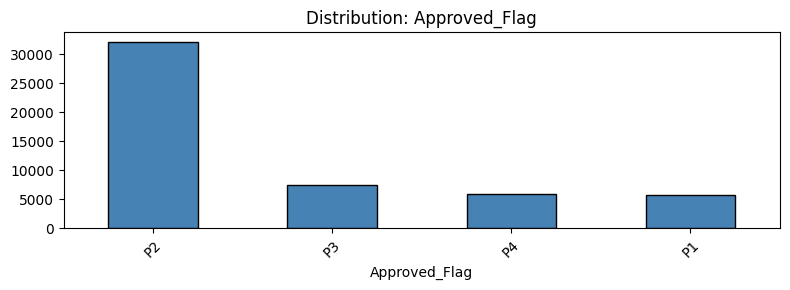

In [9]:
# Categorical — value counts
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

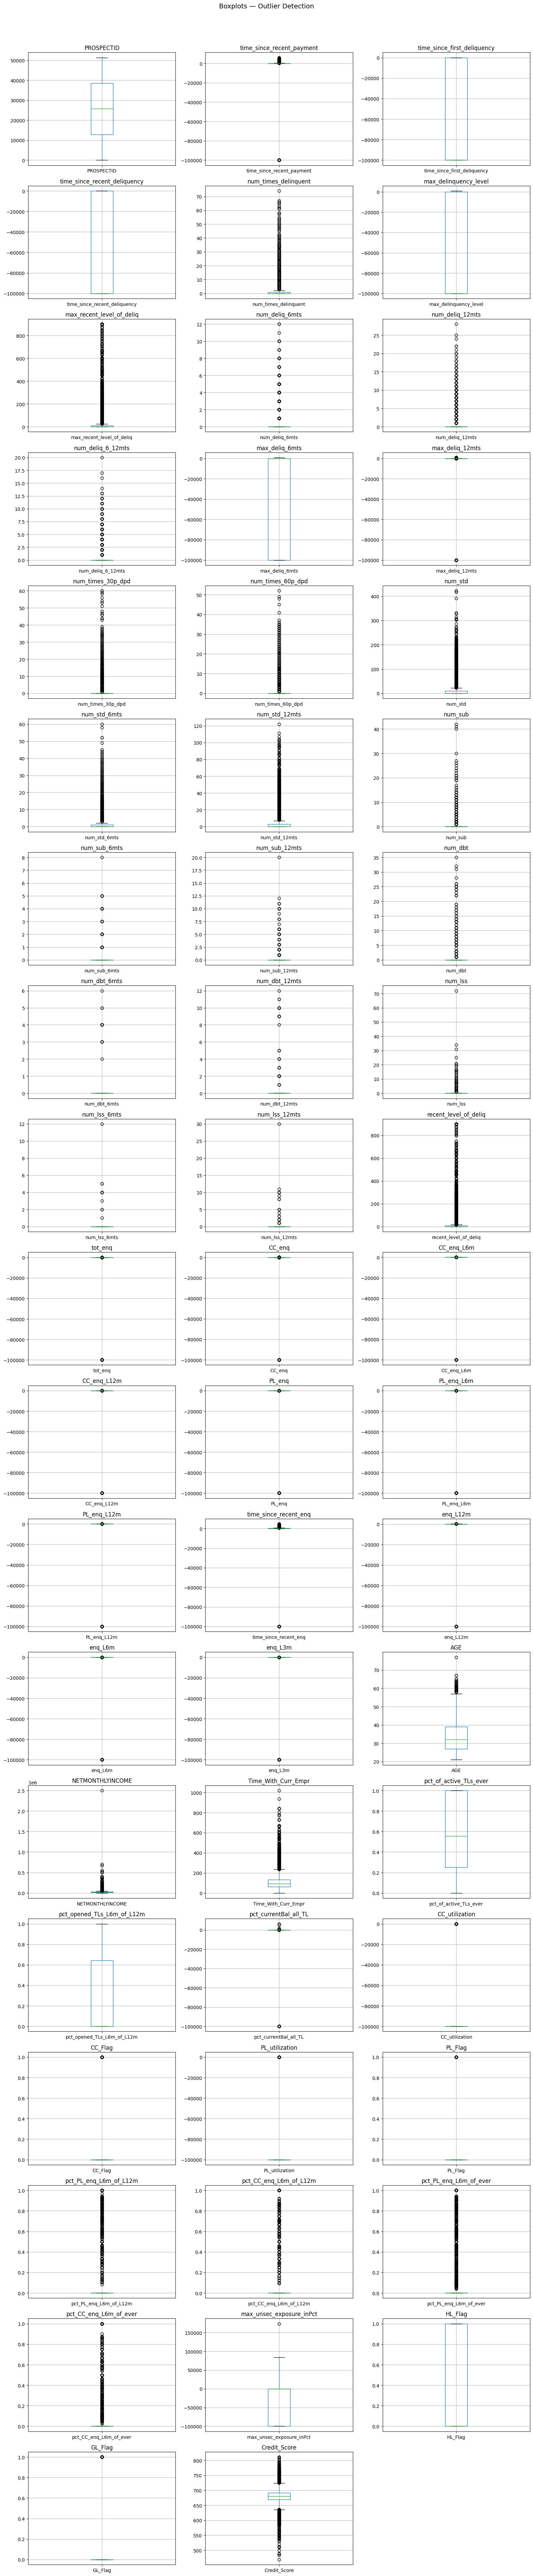

In [10]:
# Boxplots — spot outliers
fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(16, (n+2)//3 * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

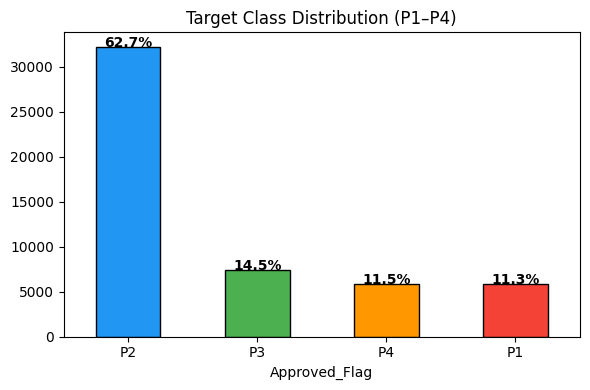

<Figure size 800x400 with 0 Axes>

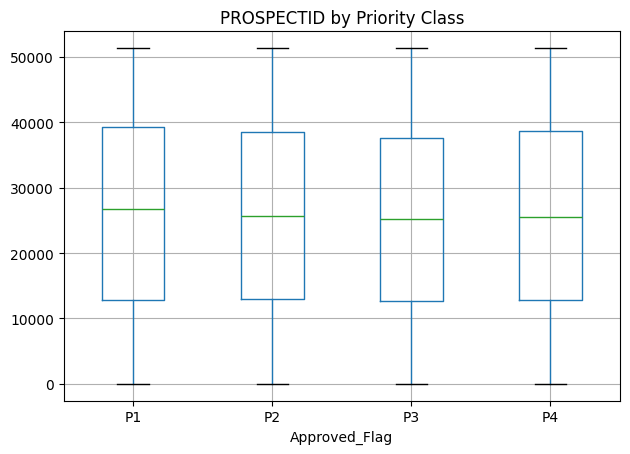

<Figure size 800x400 with 0 Axes>

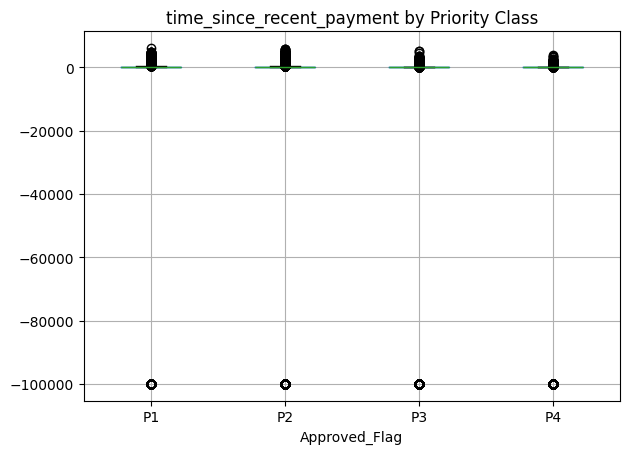

<Figure size 800x400 with 0 Axes>

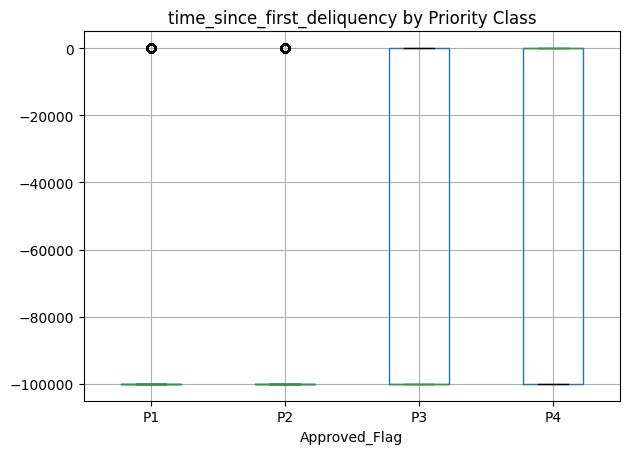

<Figure size 800x400 with 0 Axes>

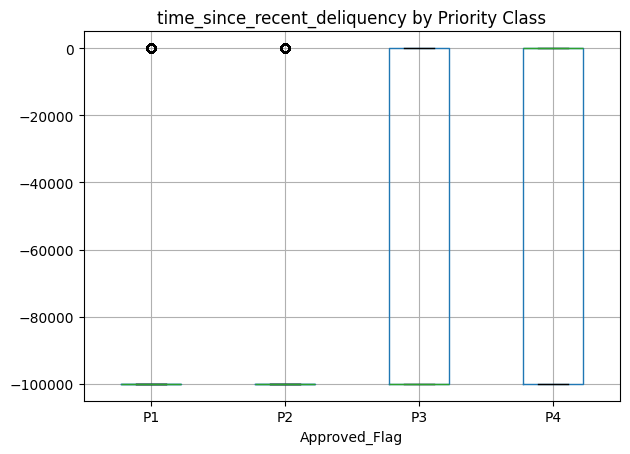

<Figure size 800x400 with 0 Axes>

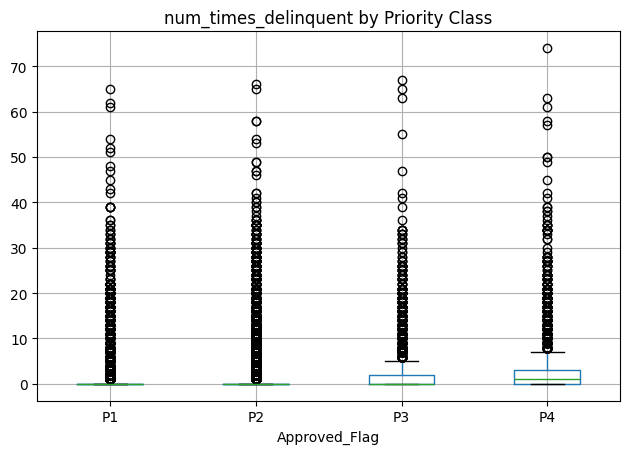

<Figure size 800x400 with 0 Axes>

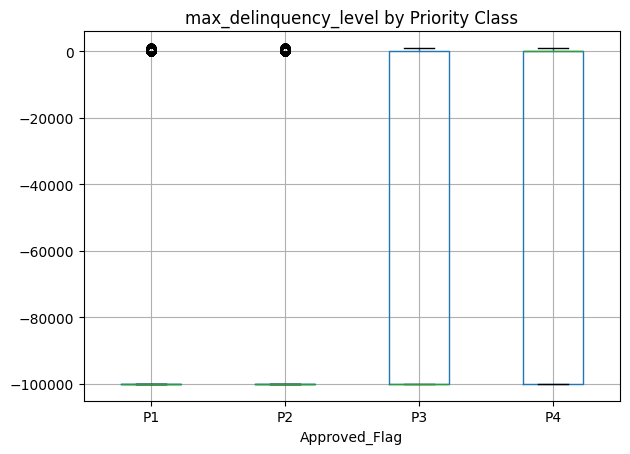

<Figure size 800x400 with 0 Axes>

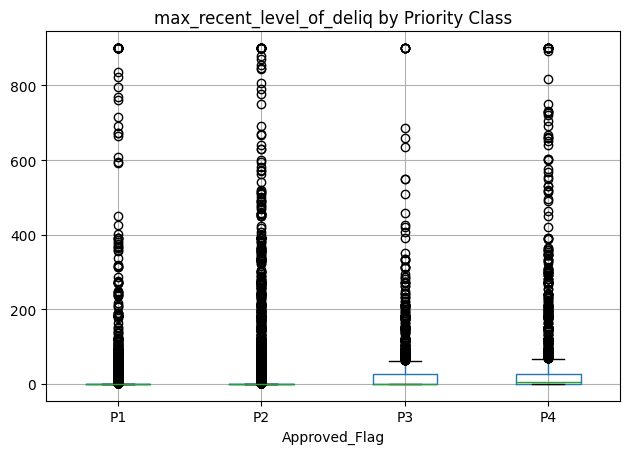

<Figure size 800x400 with 0 Axes>

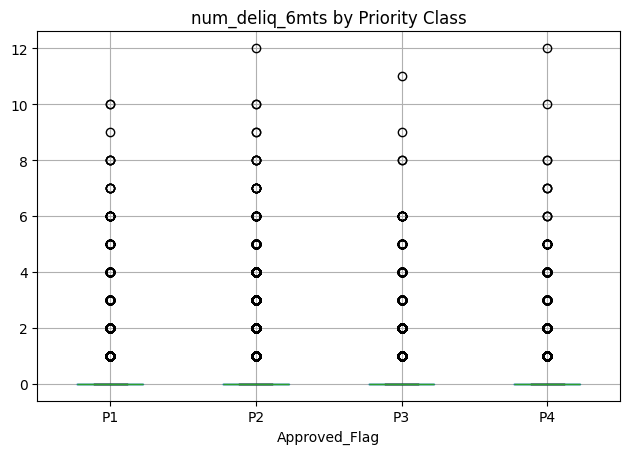

<Figure size 800x400 with 0 Axes>

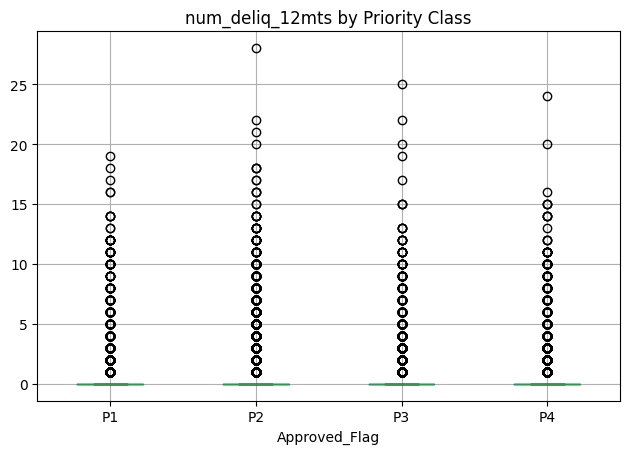

<Figure size 800x400 with 0 Axes>

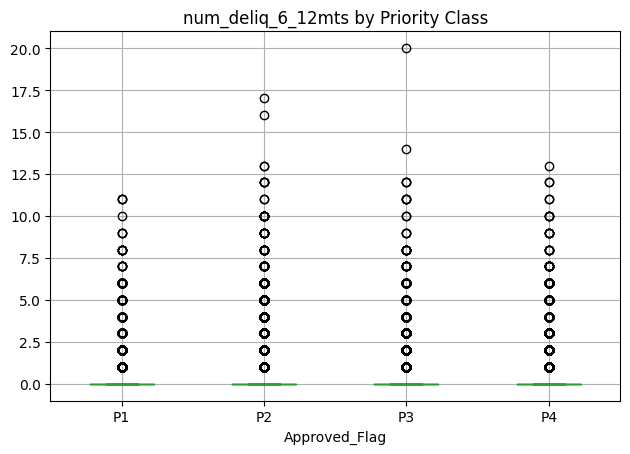

<Figure size 800x400 with 0 Axes>

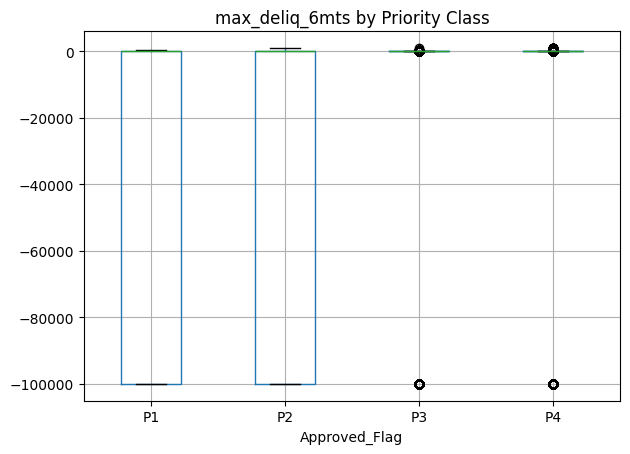

<Figure size 800x400 with 0 Axes>

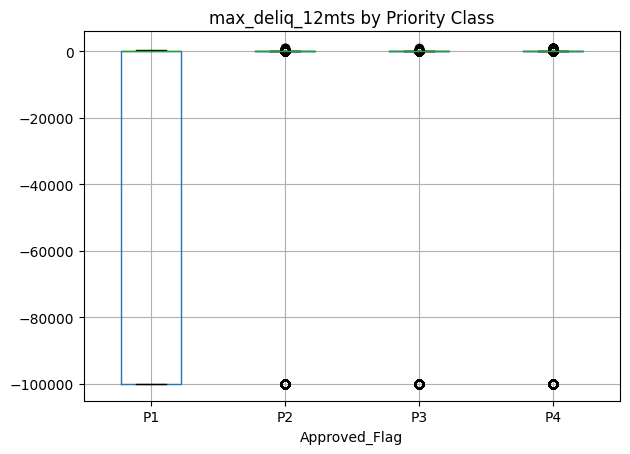

<Figure size 800x400 with 0 Axes>

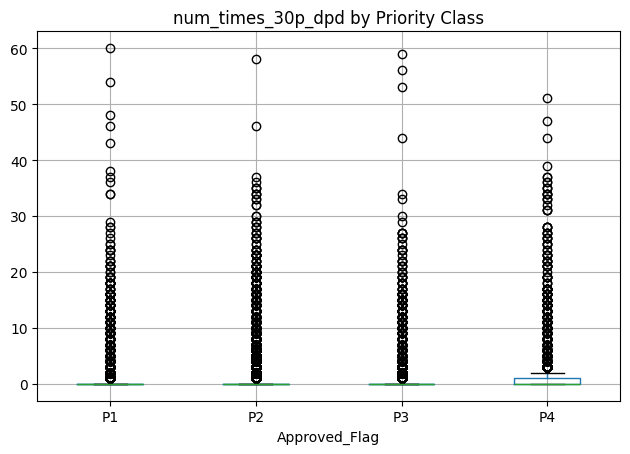

<Figure size 800x400 with 0 Axes>

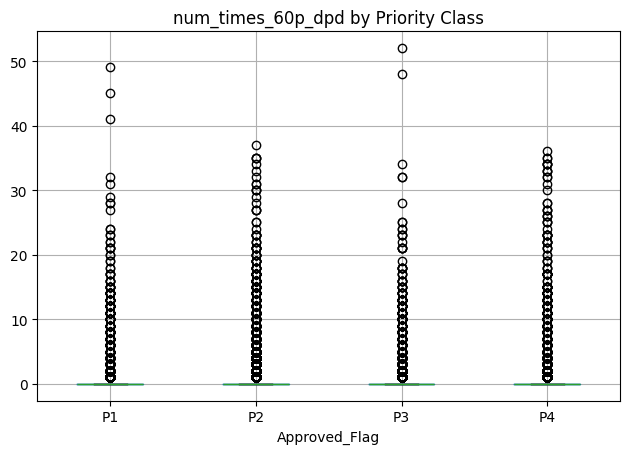

<Figure size 800x400 with 0 Axes>

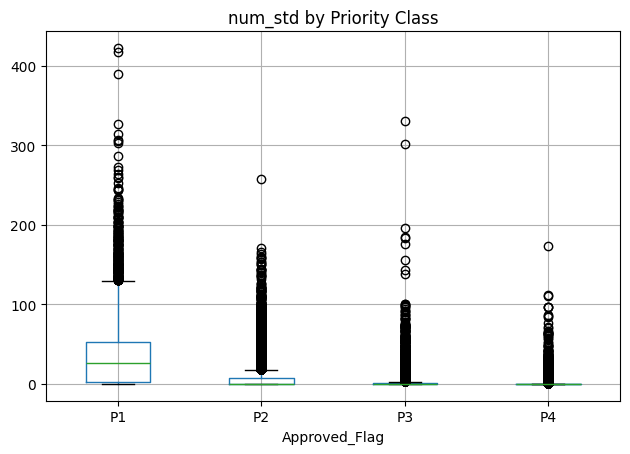

<Figure size 800x400 with 0 Axes>

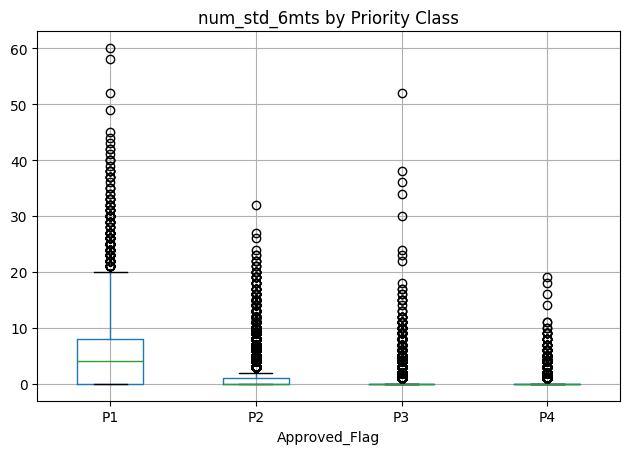

<Figure size 800x400 with 0 Axes>

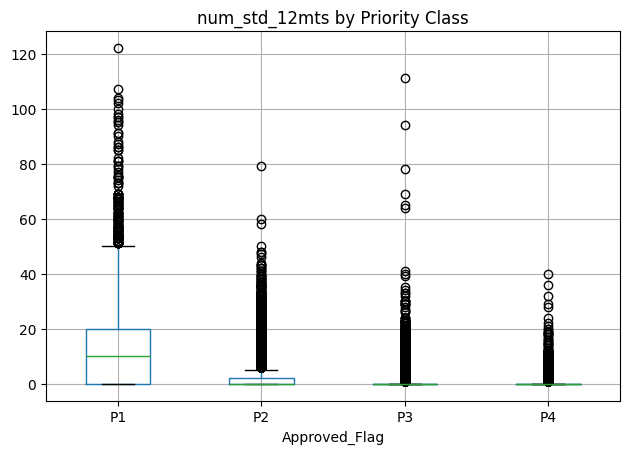

<Figure size 800x400 with 0 Axes>

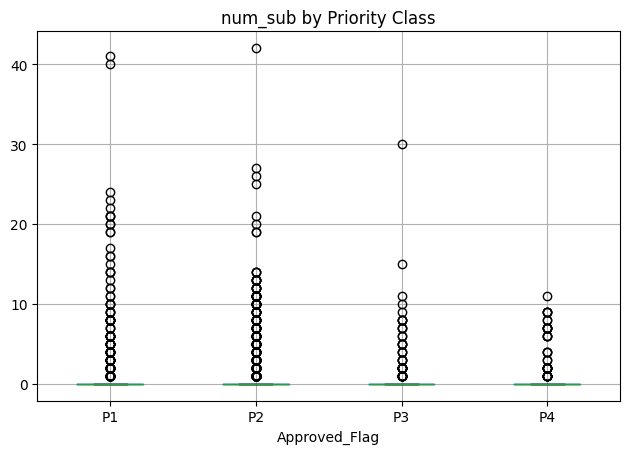

<Figure size 800x400 with 0 Axes>

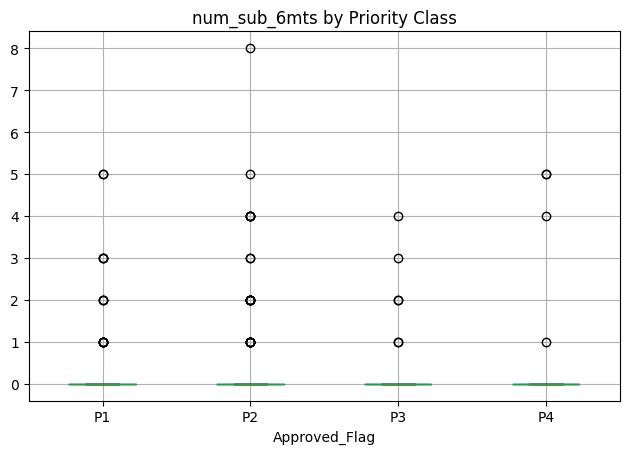

<Figure size 800x400 with 0 Axes>

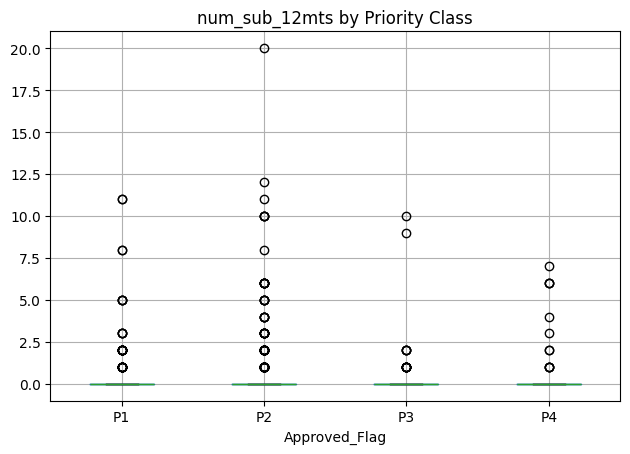

<Figure size 800x400 with 0 Axes>

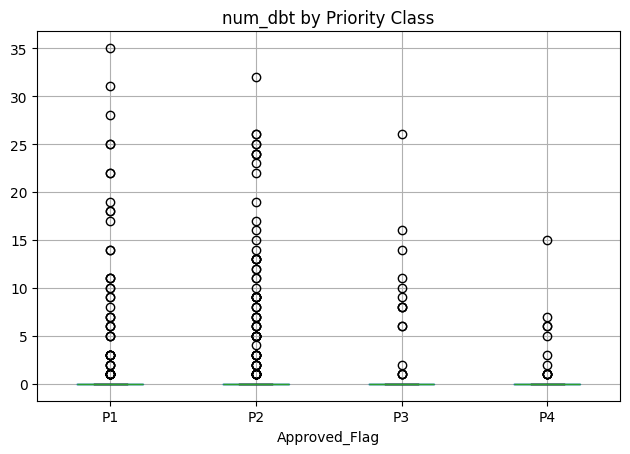

<Figure size 800x400 with 0 Axes>

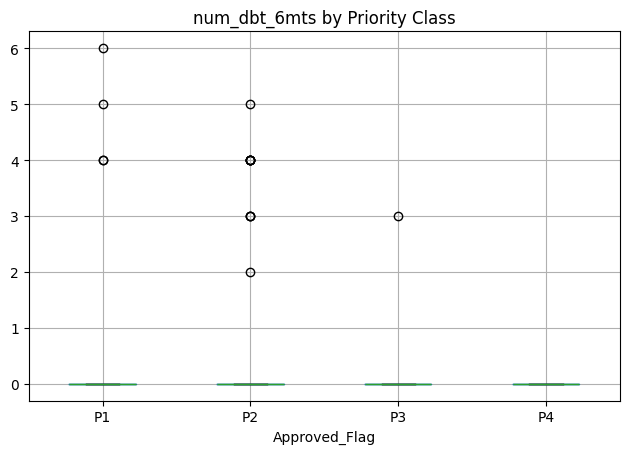

<Figure size 800x400 with 0 Axes>

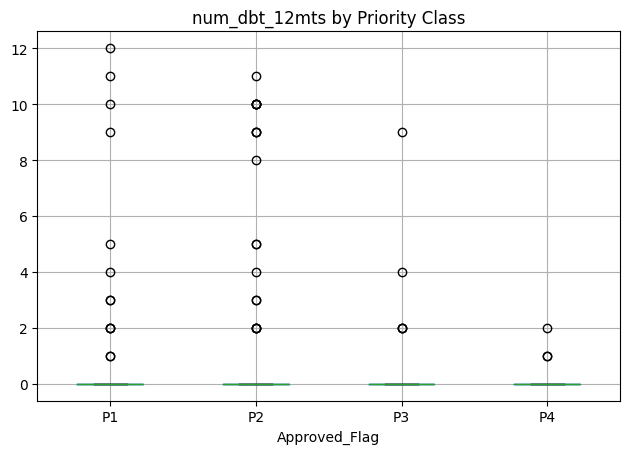

<Figure size 800x400 with 0 Axes>

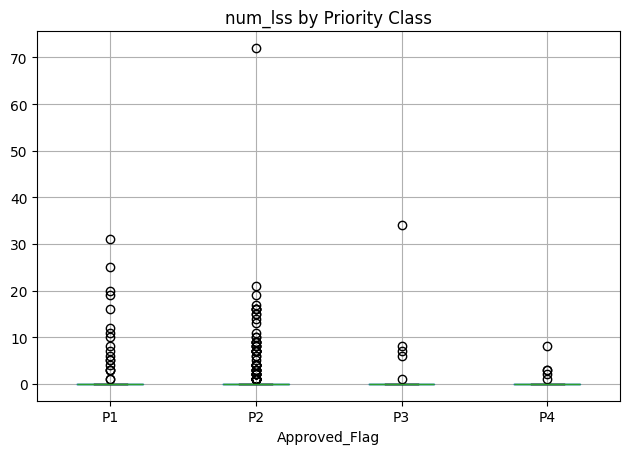

<Figure size 800x400 with 0 Axes>

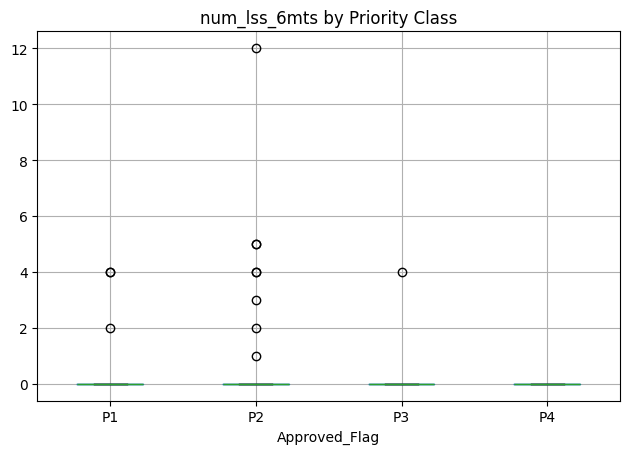

<Figure size 800x400 with 0 Axes>

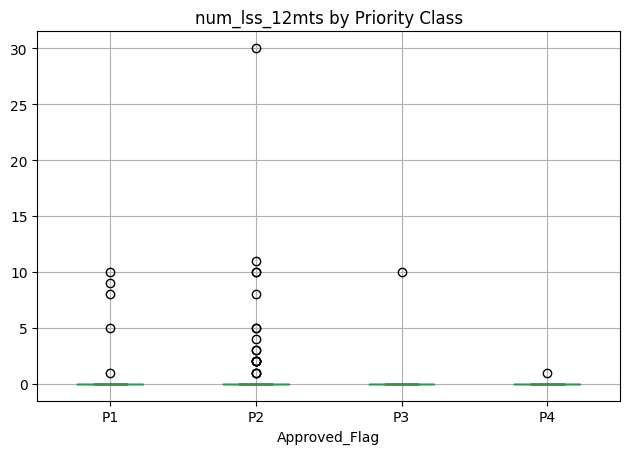

<Figure size 800x400 with 0 Axes>

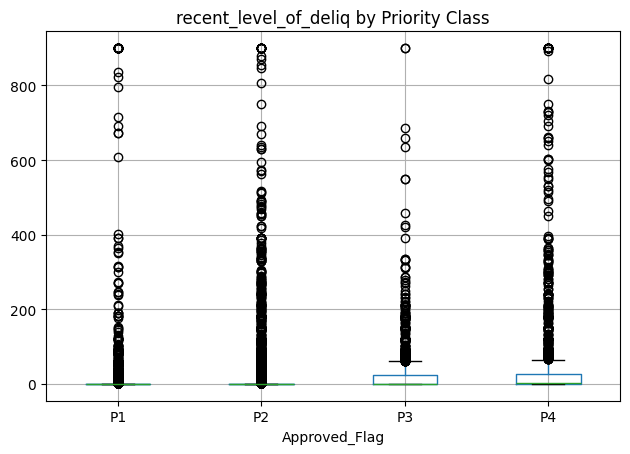

<Figure size 800x400 with 0 Axes>

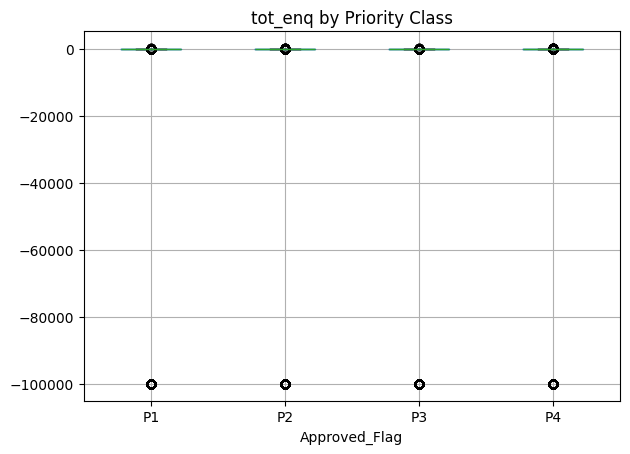

<Figure size 800x400 with 0 Axes>

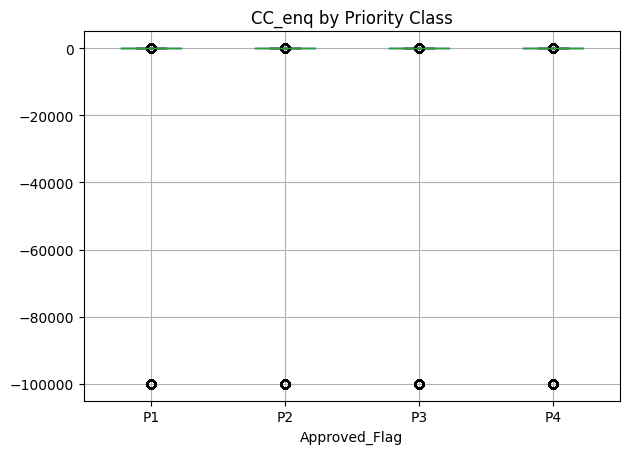

<Figure size 800x400 with 0 Axes>

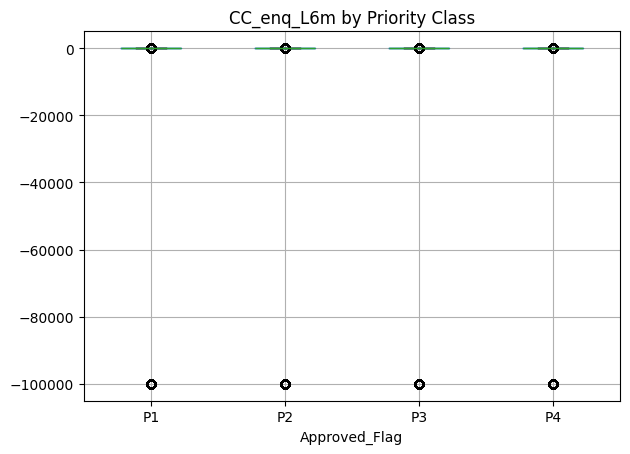

<Figure size 800x400 with 0 Axes>

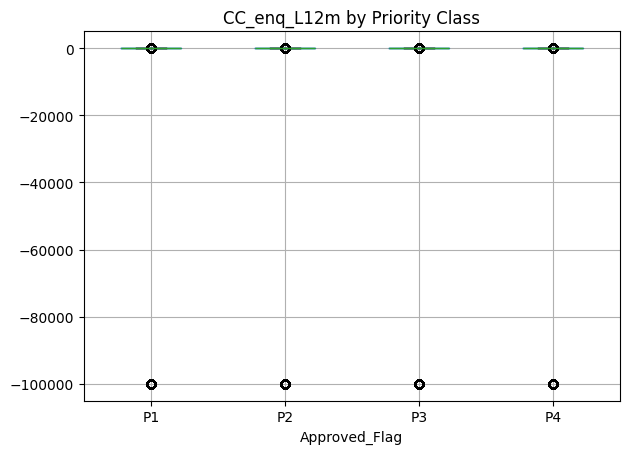

<Figure size 800x400 with 0 Axes>

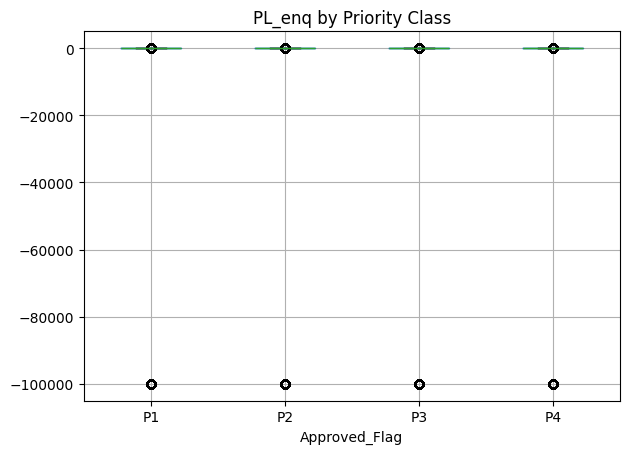

<Figure size 800x400 with 0 Axes>

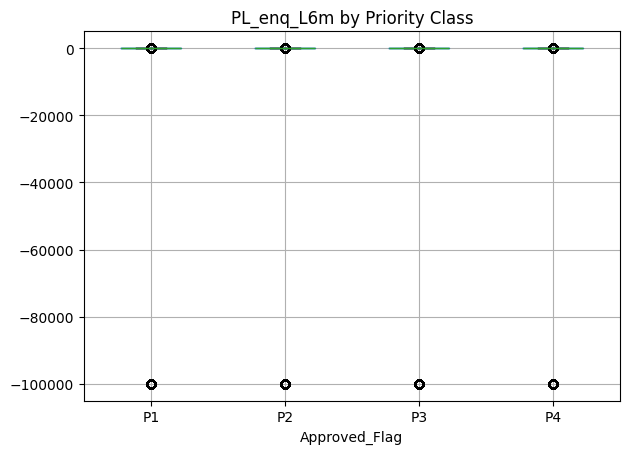

<Figure size 800x400 with 0 Axes>

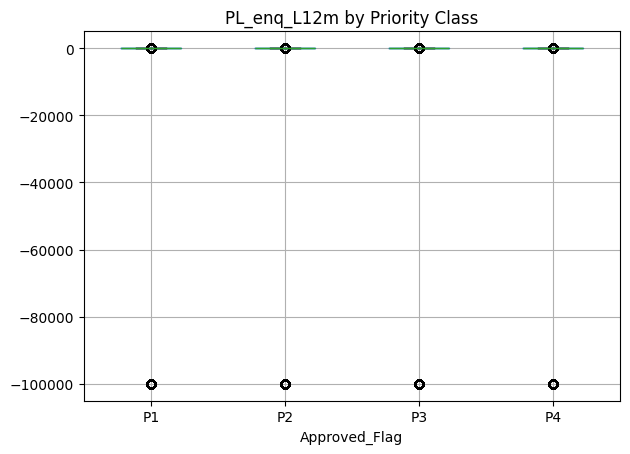

<Figure size 800x400 with 0 Axes>

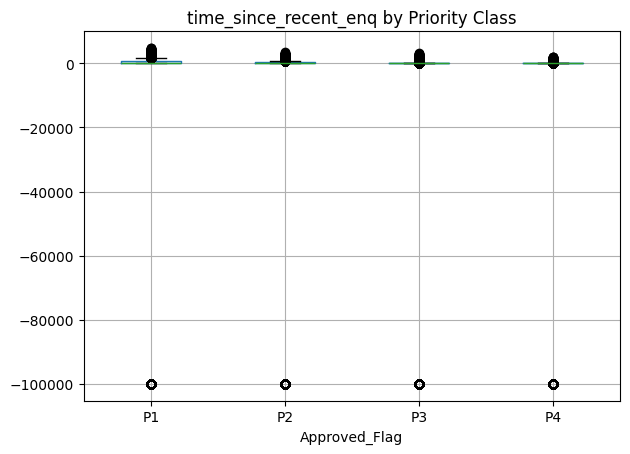

<Figure size 800x400 with 0 Axes>

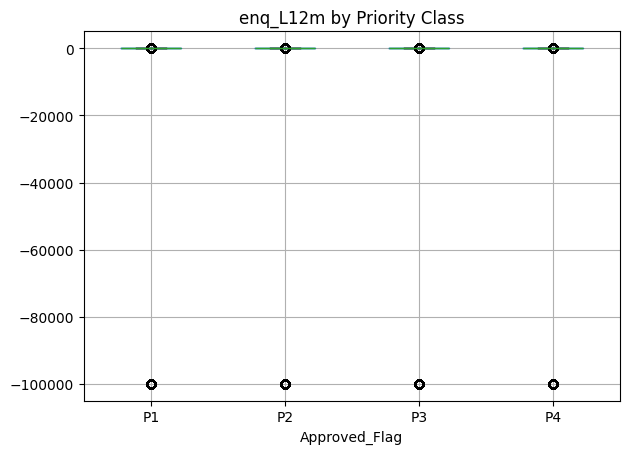

<Figure size 800x400 with 0 Axes>

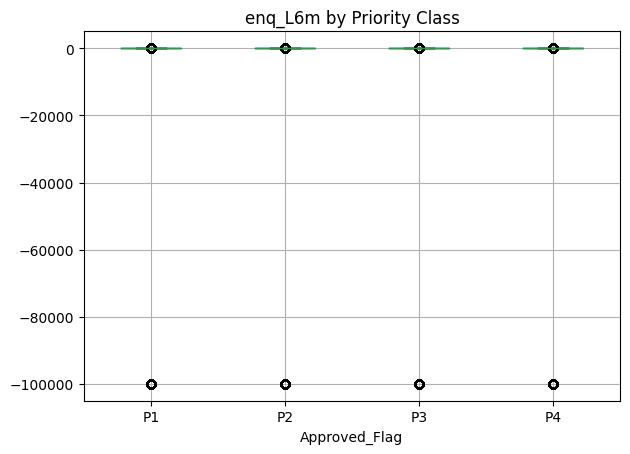

<Figure size 800x400 with 0 Axes>

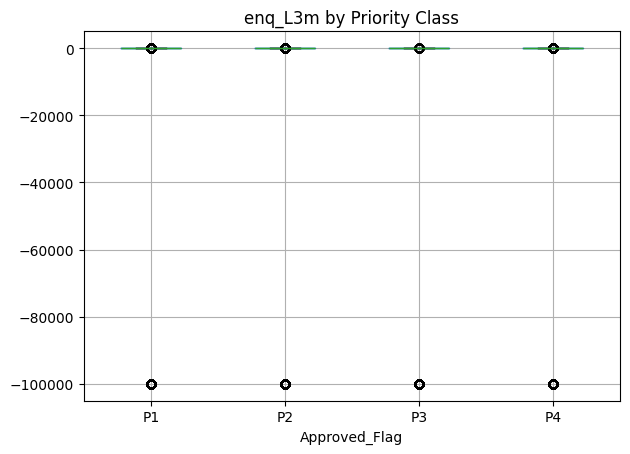

<Figure size 800x400 with 0 Axes>

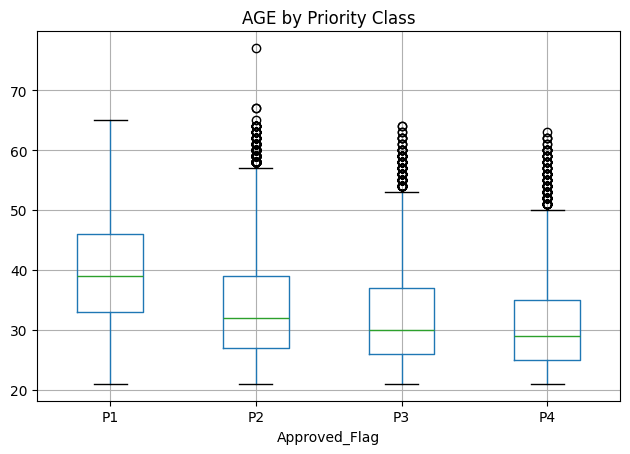

<Figure size 800x400 with 0 Axes>

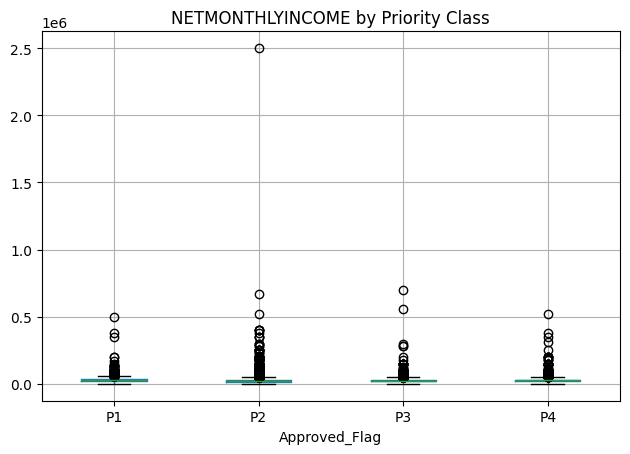

<Figure size 800x400 with 0 Axes>

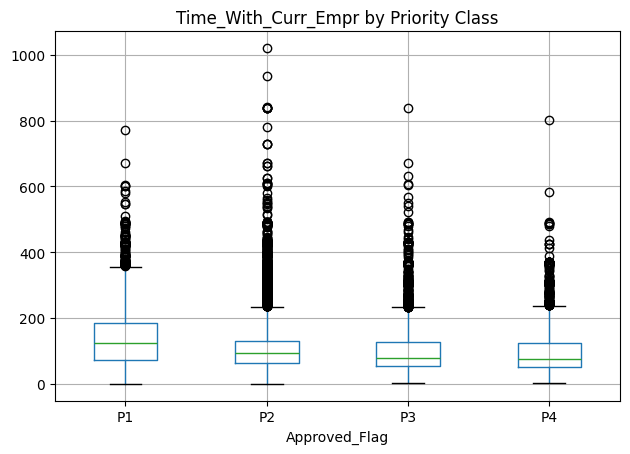

<Figure size 800x400 with 0 Axes>

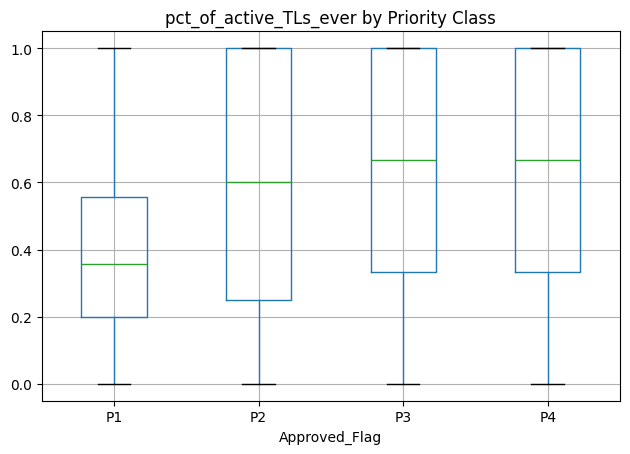

<Figure size 800x400 with 0 Axes>

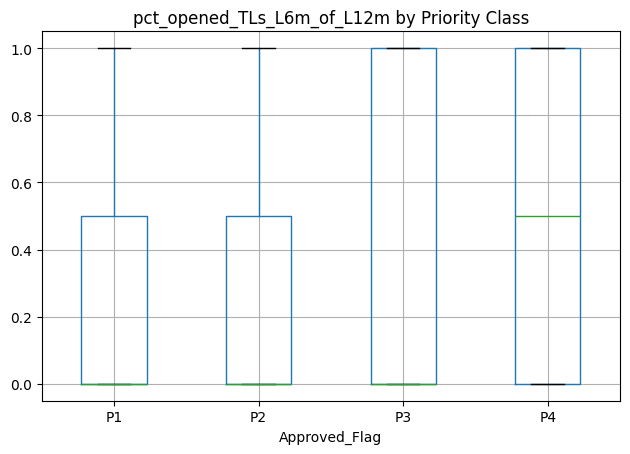

<Figure size 800x400 with 0 Axes>

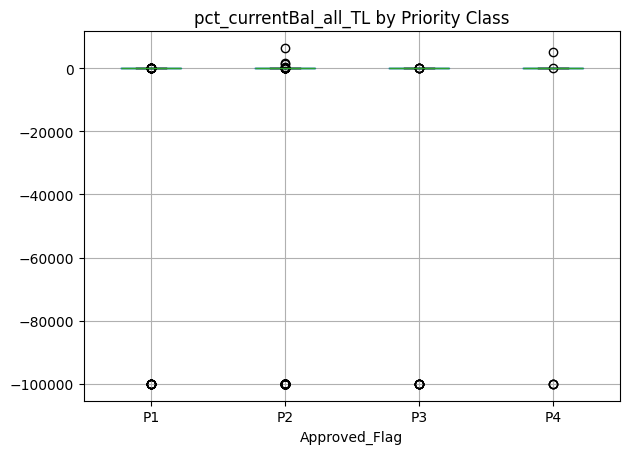

<Figure size 800x400 with 0 Axes>

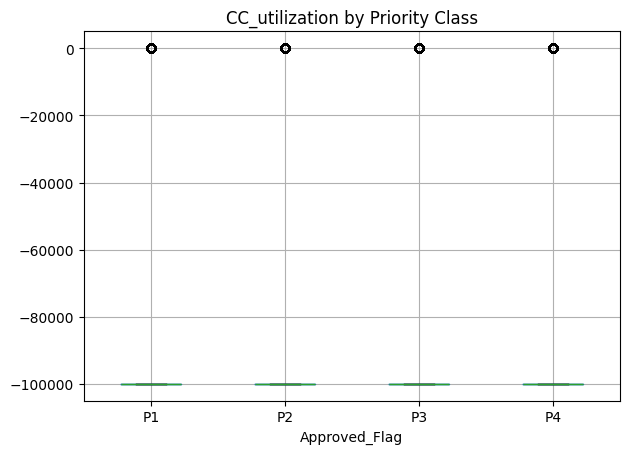

<Figure size 800x400 with 0 Axes>

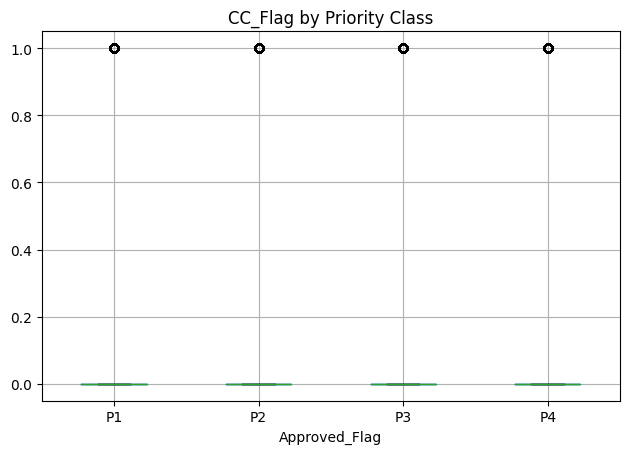

<Figure size 800x400 with 0 Axes>

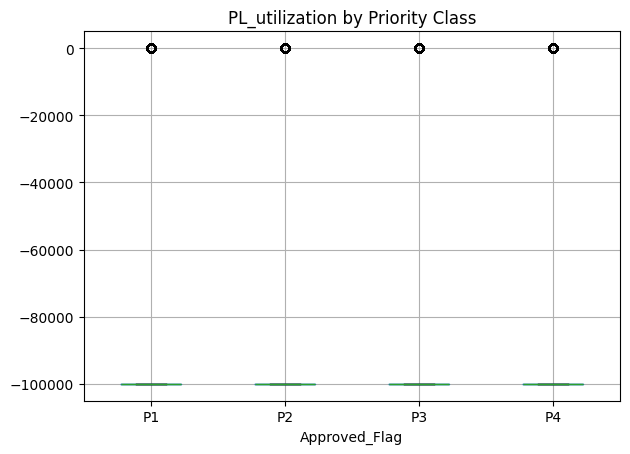

<Figure size 800x400 with 0 Axes>

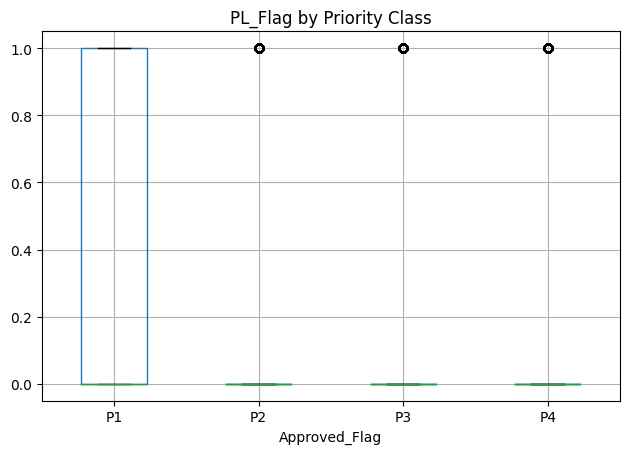

<Figure size 800x400 with 0 Axes>

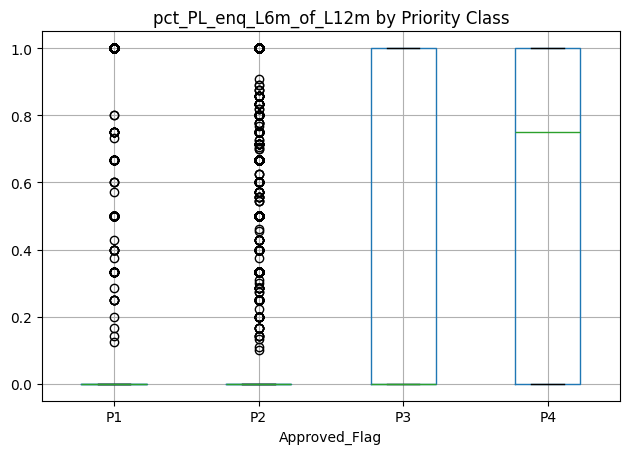

<Figure size 800x400 with 0 Axes>

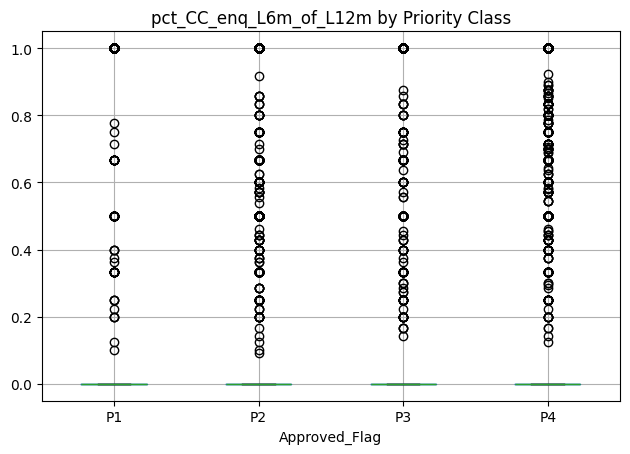

<Figure size 800x400 with 0 Axes>

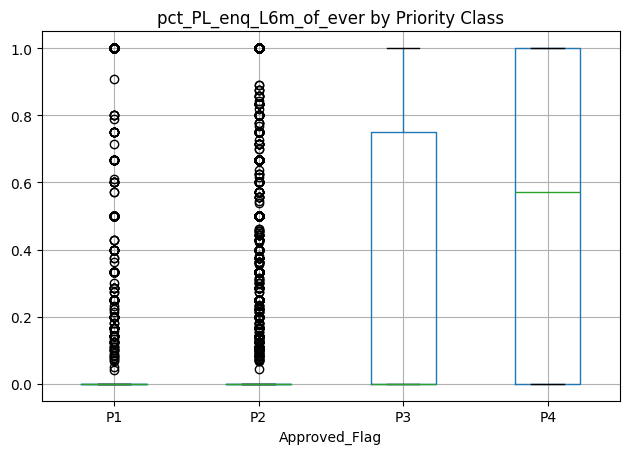

<Figure size 800x400 with 0 Axes>

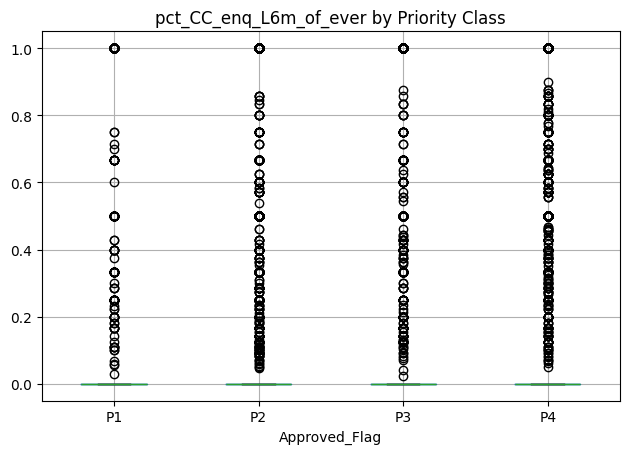

<Figure size 800x400 with 0 Axes>

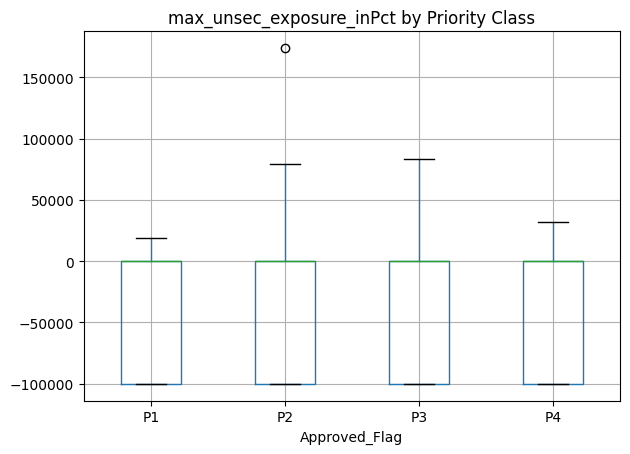

<Figure size 800x400 with 0 Axes>

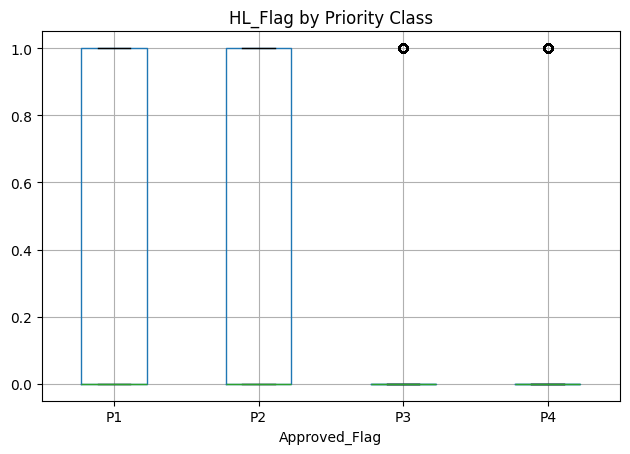

<Figure size 800x400 with 0 Axes>

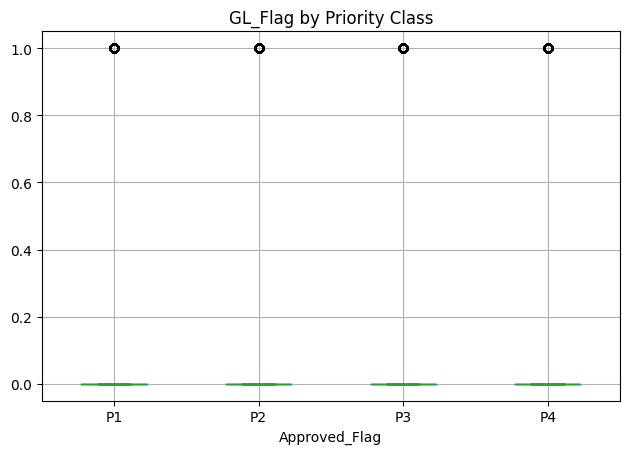

<Figure size 800x400 with 0 Axes>

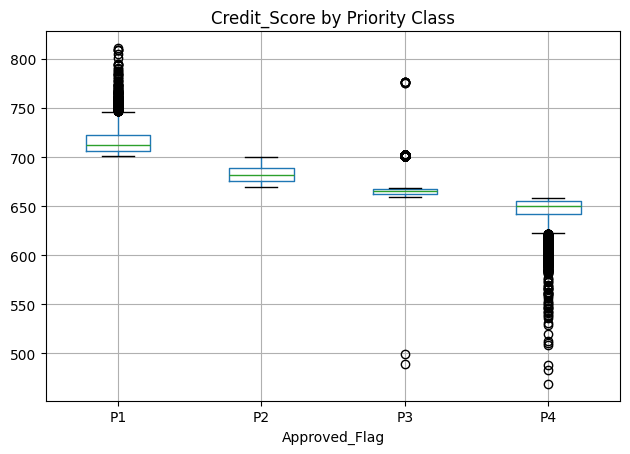

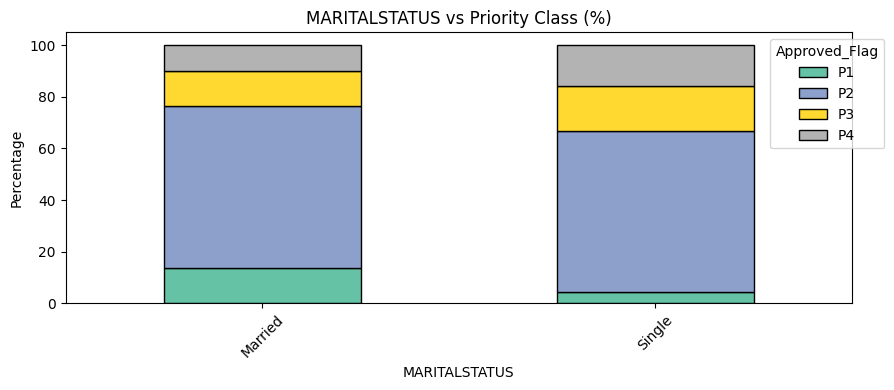

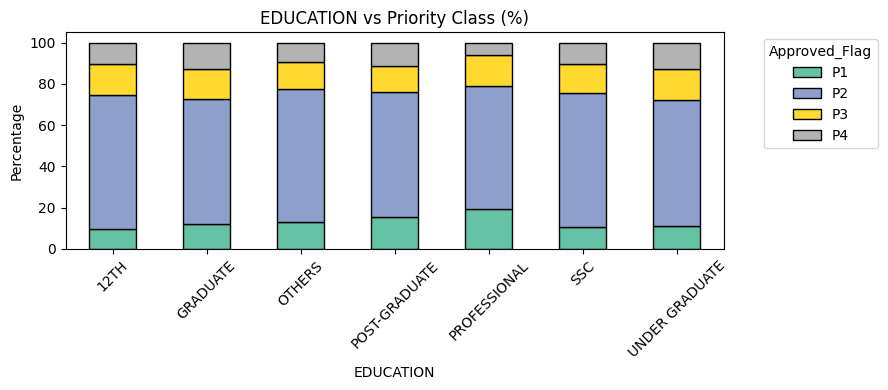

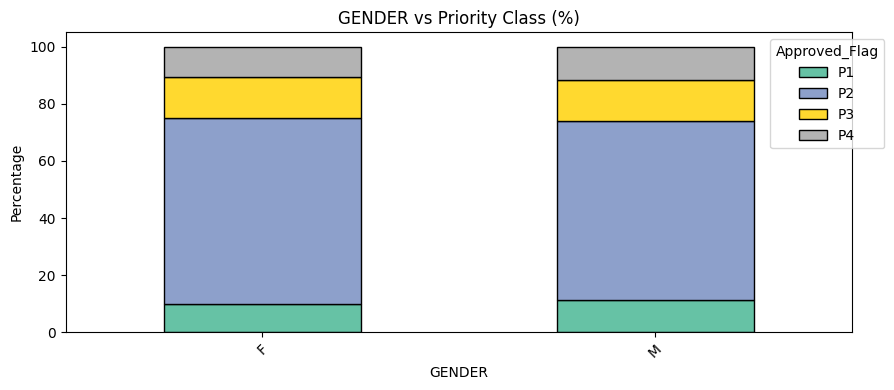

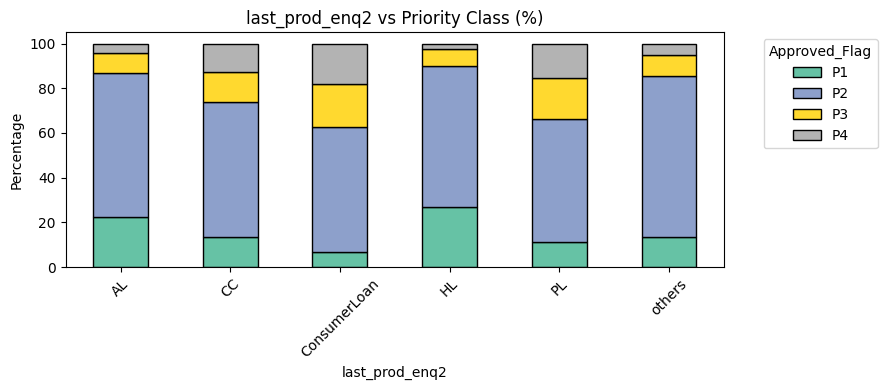

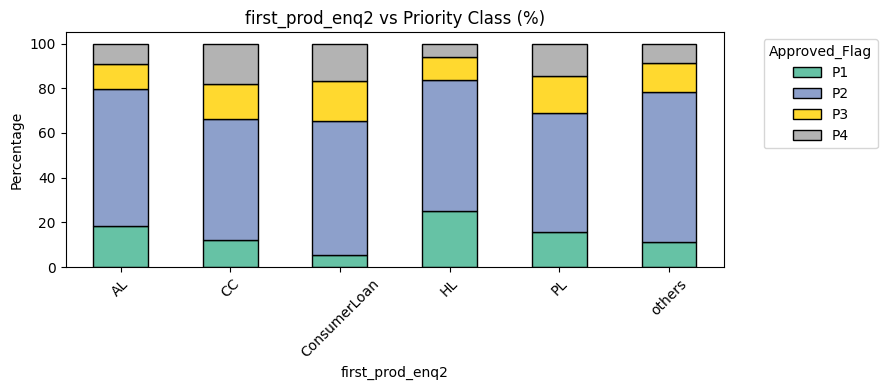

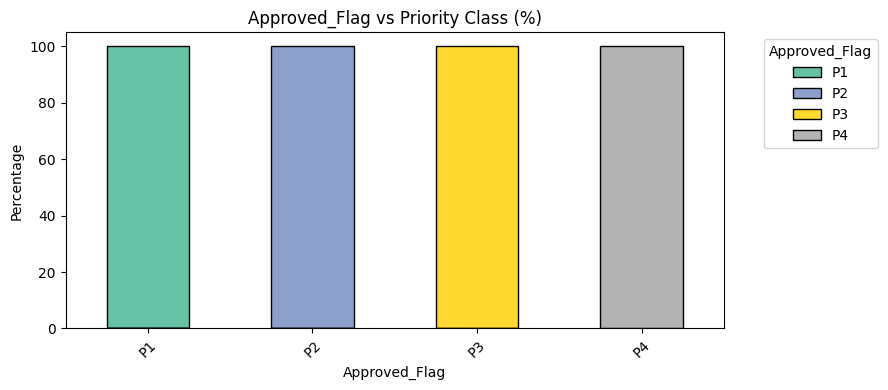

In [11]:
# Target distribution
TARGET='Approved_Flag'
plt.figure(figsize=(6, 4))
df[TARGET].value_counts().plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800','#F44336'],
                                edgecolor='black')
plt.title('Target Class Distribution (P1–P4)')
plt.xticks(rotation=0)
for i, v in enumerate(df[TARGET].value_counts()):
    plt.text(i, v + 0.5, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Numerical features by target class — boxplots
for col in num_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by=TARGET)
    plt.title(f'{col} by Priority Class')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

# Categorical features vs Target — stacked bar
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(9, 4), colormap='Set2', edgecolor='black')
    plt.title(f'{col} vs Priority Class (%)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.legend(title=TARGET, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

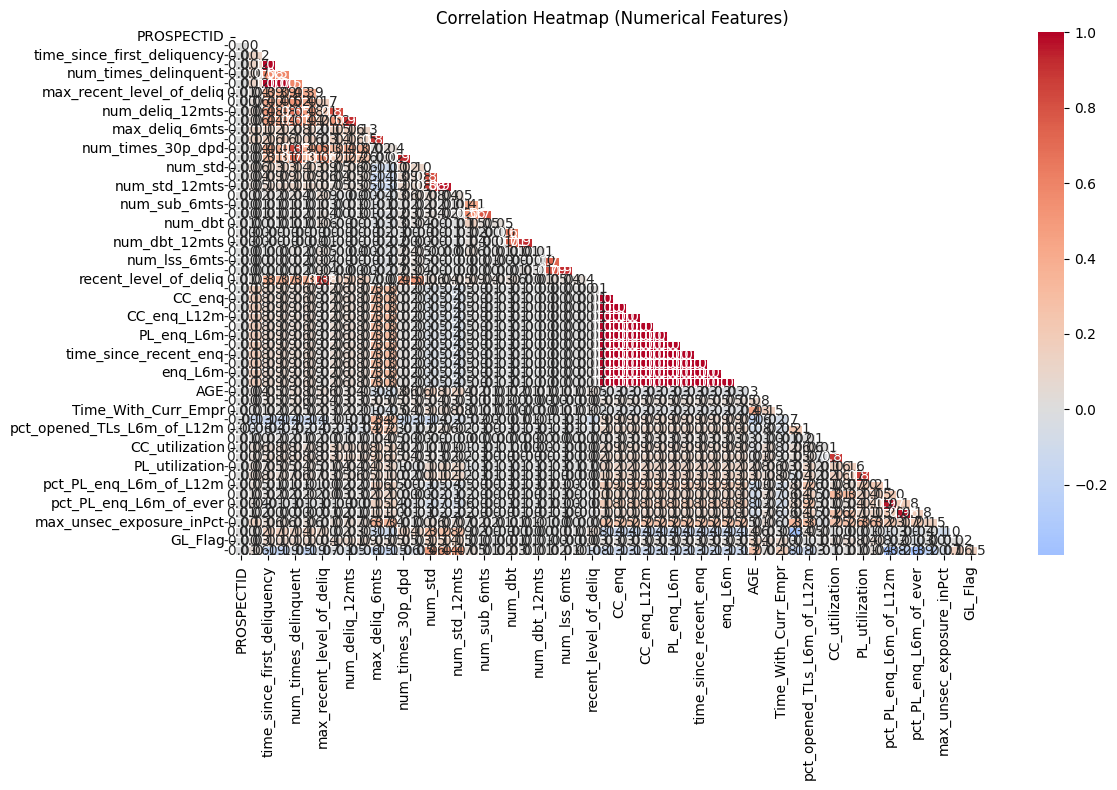


Top 10 Correlated Feature Pairs:
 CC_enq_L12m  CC_enq_L6m     1.0
PL_enq_L12m  PL_enq_L6m     1.0
CC_enq_L12m  CC_enq         1.0
PL_enq       PL_enq_L12m    1.0
PL_enq_L6m   CC_enq_L6m     1.0
CC_enq_L6m   CC_enq         1.0
CC_enq_L12m  PL_enq_L6m     1.0
PL_enq_L6m   PL_enq         1.0
CC_enq_L6m   PL_enq_L12m    1.0
PL_enq_L12m  CC_enq_L12m    1.0
dtype: float64


In [12]:
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

# Top correlated pairs
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
print("\nTop 10 Correlated Feature Pairs:\n", corr_pairs.head(10))

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\binaryLabel\label_conversion.csv")

In [4]:
df.describe()

,PROSPECTID,AGE,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,PL_Flag,pct_PL_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score,loan_status_binary
count,51336.000000,51336.000000,5.133600e+04,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,33.758532,2.642419e+04,110.707846,0.577542,0.167874,0.170492,0.271116,0.052887,679.859222,0.259740
std,14819.571046,8.816364,2.002711e+04,76.046831,0.379867,0.373758,0.350209,0.444540,0.223810,20.502764,0.438496
min,1.000000,21.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,469.000000,0.000000
25%,12834.750000,27.000000,1.800000e+04,61.000000,0.250000,0.000000,0.000000,0.000000,0.000000,669.000000,0.000000
50%,25668.500000,32.000000,2.300000e+04,93.000000,0.556000,0.000000,0.000000,0.000000,0.000000,680.000000,0.000000
75%,38502.250000,39.000000,3.000000e+04,131.000000,1.000000,0.000000,0.000000,1.000000,0.000000,691.000000,1.000000
max,51336.000000,77.000000,2.500000e+06,1020.000000,1.000000,1.000000,1.000000,1.000000,1.000000,811.000000,1.000000


In [7]:
import pandas as pd
import numpy as np
import os

input_path = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\binaryLabel\label_conversion.csv"
output_dir = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning"
output_path = os.path.join(output_dir, "External_Cibil_Dataset.csv")

df = pd.read_csv(input_path)

print("=" * 50)
print("1. MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found ✓")

print("\n" + "=" * 50)
print("2. DUPLICATES")
print("=" * 50)
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Dropped {dupes} duplicate rows ✓")

print("\n" + "=" * 50)
print("3. PROSPECTID SANITY CHECK")
print("=" * 50)
# From describe: count=51336, meaning PROSPECTID should be unique per row
id_dupes = df['PROSPECTID'].duplicated().sum()
print(f"Duplicate PROSPECTIDs: {id_dupes}")
if id_dupes > 0:
    print("WARNING: PROSPECTID is not unique — investigate before splitting!")

print("\n" + "=" * 50)
print("4. OUTLIER FLAGS (from your describe stats)")
print("=" * 50)
# NETMONTHLYINCOME: max is 2.5e+06 vs 75th pct of 2.3e+04 — extreme outlier
income_outliers = (df['NETMONTHLYINCOME'] > 200000).sum()
print(f"NETMONTHLYINCOME > 2,00,000: {income_outliers} rows")

# Time_With_Curr_Empr: max=1020 vs 75th=131 — suspicious
time_outliers = (df['Time_With_Curr_Empr'] > 600).sum()
print(f"Time_With_Curr_Empr > 600 months (50 yrs): {time_outliers} rows")

# Credit_Score: min=0 is suspicious for a credit score
zero_credit = (df['Credit_Score'] == 0).sum()
print(f"Credit_Score == 0: {zero_credit} rows")

# AGE: sanity check
age_outliers = ((df['AGE'] < 18) | (df['AGE'] > 80)).sum()
print(f"AGE outside 18–80: {age_outliers} rows")

print("\n" + "=" * 50)
print("5. TARGET DISTRIBUTION")
print("=" * 50)
print(df['loan_status_binary'].value_counts())
print(df['loan_status_binary'].value_counts(normalize=True) * 100)

print("\n" + "=" * 50)
print("6. FLAG COLUMNS SANITY (should only be 0 or 1)")
print("=" * 50)
flag_cols = ['PL_Flag', 'HL_Flag', 'GL_Flag']
for col in flag_cols:
    unique_vals = df[col].unique()
    print(f"{col} unique values: {unique_vals}")

os.makedirs(output_dir, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"\nClean dataset saved to: {output_path}")
print(f"Final shape: {df.shape}")

1. MISSING VALUES
No missing values found ✓

2. DUPLICATES
Duplicate rows: 0

3. PROSPECTID SANITY CHECK
Duplicate PROSPECTIDs: 0

4. OUTLIER FLAGS (from your describe stats)
NETMONTHLYINCOME > 2,00,000: 40 rows
Time_With_Curr_Empr > 600 months (50 yrs): 35 rows
Credit_Score == 0: 0 rows
AGE outside 18–80: 0 rows

5. TARGET DISTRIBUTION
loan_status_binary
0    38002
1    13334
Name: count, dtype: int64
loan_status_binary
0    74.026025
1    25.973975
Name: proportion, dtype: float64

6. FLAG COLUMNS SANITY (should only be 0 or 1)
PL_Flag unique values: [1 0]
HL_Flag unique values: [1 0]
GL_Flag unique values: [0 1]

Clean dataset saved to: C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning\External_Cibil_Dataset.csv
Final shape: (51336, 15)


In [8]:
import pandas as pd
import numpy as np
import os

input_path = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\binaryLabel\label_conversion.csv"
output_dir = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning"
output_path = os.path.join(output_dir, "Cleaned_External_Cibil_Dataset.csv")

df = pd.read_csv(input_path)
original_shape = df.shape


print("BEFORE CLEANING")

print(f"Shape: {df.shape}")
print(f"NETMONTHLYINCOME > 2,00,000: {(df['NETMONTHLYINCOME'] > 200000).sum()} rows")
print(f"Time_With_Curr_Empr > 600: {(df['Time_With_Curr_Empr'] > 600).sum()} rows")

print("\n" )
print("HANDLING NETMONTHLYINCOME OUTLIERS (40 rows)")

# Cap at 99th percentile instead of dropping — preserves data, reduces skew
cap_income = df['NETMONTHLYINCOME'].quantile(0.99)
df['NETMONTHLYINCOME'] = df['NETMONTHLYINCOME'].clip(upper=cap_income)
print(f"Capped NETMONTHLYINCOME at 99th percentile: {cap_income:,.0f}")

print("\n")
print("HANDLING Time_With_Curr_Empr OUTLIERS (35 rows)")

# These are likely data entry errors (e.g., days entered instead of months)
# Cap at a realistic max: 480 months = 40 years working life
cap_time = df['Time_With_Curr_Empr'].quantile(0.99)
df['Time_With_Curr_Empr'] = df['Time_With_Curr_Empr'].clip(upper=cap_time)
print(f"Capped Time_With_Curr_Empr at 99th percentile: {cap_time:,.0f} months")


print("AFTER CLEANING")
print(f"Shape: {df.shape}  (no rows dropped — outliers capped)")
print(f"NETMONTHLYINCOME > 2,00,000: {(df['NETMONTHLYINCOME'] > 200000).sum()} rows")
print(f"Time_With_Curr_Empr > 600: {(df['Time_With_Curr_Empr'] > 600).sum()} rows")
print(f"\nNETMONTHLYINCOME stats after capping:")
print(df['NETMONTHLYINCOME'].describe())
print(f"\nTime_With_Curr_Empr stats after capping:")
print(df['Time_With_Curr_Empr'].describe())

os.makedirs(output_dir, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"\nSaved cleaned dataset to: {output_path}")

BEFORE CLEANING
Shape: (51336, 15)
NETMONTHLYINCOME > 2,00,000: 40 rows
Time_With_Curr_Empr > 600: 35 rows


HANDLING NETMONTHLYINCOME OUTLIERS (40 rows)
Capped NETMONTHLYINCOME at 99th percentile: 78,000


HANDLING Time_With_Curr_Empr OUTLIERS (35 rows)
Capped Time_With_Curr_Empr at 99th percentile: 369 months
AFTER CLEANING
Shape: (51336, 15)  (no rows dropped — outliers capped)
NETMONTHLYINCOME > 2,00,000: 0 rows
Time_With_Curr_Empr > 600: 0 rows

NETMONTHLYINCOME stats after capping:
count    51336.000000
mean     25951.967041
std      12623.133586
min          0.000000
25%      18000.000000
50%      23000.000000
75%      30000.000000
max      78000.000000
Name: NETMONTHLYINCOME, dtype: float64

Time_With_Curr_Empr stats after capping:
count    51336.000000
mean       110.013636
std         72.740781
min          0.000000
25%         61.000000
50%         93.000000
75%        131.000000
max        369.000000
Name: Time_With_Curr_Empr, dtype: float64

Saved cleaned dataset to: C:\Us

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

input_path = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning\Cleaned_External_Cibil_Dataset.csv"
output_dir = r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits"

df = pd.read_csv(input_path)

X = df.drop(columns=['loan_status_binary'])
y = df['loan_status_binary']

# Split: 70% train, 15% val, 15% test — all stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("=" * 50)
print("SPLIT SIZES")
print("=" * 50)
print(f"Train : {X_train.shape[0]:>6} rows ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:>6} rows ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:>6} rows ({len(X_test)/len(df)*100:.1f}%)")

print("\n" + "=" * 50)
print("STRATIFICATION CHECK (target distribution per split)")
print("=" * 50)
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = y_split.value_counts(normalize=True) * 100
    print(f"{name:5} → class 0: {dist[0]:.1f}%  class 1: {dist[1]:.1f}%")

os.makedirs(output_dir, exist_ok=True)
X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_val.to_csv(os.path.join(output_dir, "X_val.csv"),   index=False)
X_test.to_csv(os.path.join(output_dir, "X_test.csv"),  index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_val.to_csv(os.path.join(output_dir, "y_val.csv"),   index=False)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"),  index=False)

print(f"\nAll 6 files saved to: {output_dir}")

SPLIT SIZES
Train :  35935 rows (70.0%)
Val   :   7700 rows (15.0%)
Test  :   7701 rows (15.0%)

STRATIFICATION CHECK (target distribution per split)
Train → class 0: 74.0%  class 1: 26.0%
Val   → class 0: 74.0%  class 1: 26.0%
Test  → class 0: 74.0%  class 1: 26.0%

All 6 files saved to: C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits


In [4]:


import pandas as pd

df = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits\X_train.csv")

for col in ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2']:
    print(f"{col}: {df[col].unique()}")

MARITALSTATUS: ['Single' 'Married']
EDUCATION: ['GRADUATE' '12TH' 'POST-GRADUATE' 'UNDER GRADUATE' 'OTHERS' 'SSC'
 'PROFESSIONAL']
GENDER: ['M' 'F']
last_prod_enq2: ['ConsumerLoan' 'others' 'PL' 'CC' 'AL' 'HL']


In [1]:
import pandas as pd

X_train = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits\X_train.csv")
y_train = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits\y_train.csv").squeeze()

print(X_train.corrwith(y_train).abs().sort_values(ascending=False).head(10))

Credit_Score                   0.644043
pct_PL_enq_L6m_of_ever         0.382079
last_prod_enq2_others          0.213523
last_prod_enq2_ConsumerLoan    0.191028
AGE                            0.134885
Time_With_Curr_Empr            0.100106
MARITALSTATUS_Single           0.095458
last_prod_enq2_PL              0.078648
pct_of_active_TLs_ever         0.072833
GL_Flag                        0.055017
dtype: float64


In [4]:
import pandas as pd

sens = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning02\sensitive_features.csv")
X_test = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits\X_test.csv")

print(sens.shape)
print(X_test.shape)
print(sens.head(3))
print(X_test.head(3))

(51336, 4)
(7701, 22)
   PROSPECTID GENDER MARITALSTATUS  AGE
0           1      M       Married   48
1           2      F        Single   23
2           3      M       Married   40
   AGE  NETMONTHLYINCOME  Time_With_Curr_Empr  pct_of_active_TLs_ever  \
0   26             24000                   69                     0.5   
1   31             30000                  131                     0.5   
2   31             16500                   50                     1.0   

   PL_Flag  pct_PL_enq_L6m_of_ever  HL_Flag  GL_Flag  Credit_Score  \
0        0                    0.75        0        0           655   
1        0                    0.00        0        0           676   
2        0                    0.00        0        0           683   

   MARITALSTATUS_Single  ...  EDUCATION_POST-GRADUATE  EDUCATION_PROFESSIONAL  \
0                   0.0  ...                      0.0                     0.0   
1                   0.0  ...                      0.0                     0.0   
2

In [ ]:
import pandas as pd

ids_test = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\splits\X_test_ids.csv")
sens     = pd.read_csv(r"C:\Users\projects\Fairness-Aware-Loan-Prediction-\data\processed\cleaning02\sensitive_features.csv")

merged = ids_test.merge(sens, on='PROSPECTID', how='left')
print(merged.shape)
print(merged.isnull().sum())
print(merged.head(3))